In [67]:
# Levi Félix Barbosa - 579420

import numpy as np 
import matplotlib.pyplot as plt  

nasa = np.genfromtxt('kc2.csv', delimiter=',')

X_puro = nasa[:,:-1]
y_puro = nasa[:,-1]

N = len(X_puro)

np.random.seed(42)
indices = np.random.permutation(N)
X = X_puro[indices]
y = y_puro[indices]

tam_treino = int(0.8*N)
tam_teste = N - tam_treino

X_treino = X[:tam_treino]
y_treino = y[:tam_treino]

X_teste = X[tam_treino:]
y_teste = y[tam_treino:]

In [68]:
def dist_euclidiana(X_treino, x_novo):
    
    return np.sqrt(np.sum((X_treino - x_novo)**2, axis=1))

def dist_mahalanobis(X_treino, x_novo, V_inv):
    delta = X_treino - x_novo
    dist = np.sqrt(np.sum(np.dot(delta, V_inv) * delta, axis=1))
    return dist

# knn

def knn(X_treino, y_treino, x_novo, k, dist, V_inv=None):
    if dist == 'euclidiana':
        distancias = dist_euclidiana(X_treino, x_novo)
    else:
        distancias = dist_mahalanobis(X_treino, x_novo, V_inv)

    indices_vizinhos = np.argsort(distancias)[:k]
    classes_vizinhos = y_treino[indices_vizinhos]
    if np.mean(classes_vizinhos) > 0.5:
        return 1
    return 0


In [69]:
k_folds = 10
tamanho_fold = tam_treino // k_folds

def metricas(y_real, y_pred):
    y_pred = np.array(y_pred)
    vp = np.sum((y_real == 1) & (y_pred == 1))
    vn = np.sum((y_real == 0) & (y_pred == 0))
    fp = np.sum((y_real == 0) & (y_pred == 1))
    fn = np.sum((y_real == 1) & (y_pred == 0))
    
    acuracia = (vp + vn) / len(y_real)
    precisao = vp / (vp + fp) if (vp + fp) > 0 else 0
    revocacao = vp / (vp + fn) if (vp + fn) > 0 else 0
    f1 = 2 * (precisao * revocacao) / (precisao + revocacao) if (precisao + revocacao) > 0 else 0
    
    return acuracia, revocacao, precisao, f1

# KNN
from sklearn import tree    

res_k1_euc = {'acc': [], 'rec': [], 'prec': [], 'f1': []}
res_k5_euc = {'acc': [], 'rec': [], 'prec': [], 'f1': []}
res_k1_mahal = {'acc': [], 'rec': [], 'prec': [], 'f1': []} 
res_k5_mahal = {'acc': [], 'rec': [], 'prec': [], 'f1': []}

res_gini = {'acc': [], 'rec': [], 'prec': [], 'f1': []}
res_entr = {'acc': [], 'rec': [], 'prec': [], 'f1': []}


for i in range(k_folds):
    inicio = i * tamanho_fold
    fim = (i + 1) * tamanho_fold
    
    X_teste_f = X_treino[inicio:fim]
    y_teste_f = y_treino[inicio:fim]
    
    X_treino_f = np.concatenate([X_treino[:inicio], X_treino[fim:]], axis=0)
    y_treino_f = np.concatenate([y_treino[:inicio], y_treino[fim:]], axis=0)

    media_tr = X_treino_f.mean(axis=0)
    std_tr = X_treino_f.std(axis=0)
    
    X_treinof_norm = (X_treino_f - media_tr) / std_tr
    X_testef_norm = (X_teste_f - media_tr) / std_tr

    
    S = np.cov(X_treinof_norm.T) + np.eye(X_treinof_norm.shape[1])
    V_inv = np.linalg.inv(S)

    preds_k1_euc = []
    preds_k5_euc = []
    preds_k1_mahal = []
    preds_k5_mahal = [] 

    for x_val in X_testef_norm:
        # k=1, euclidiana
        p1 = knn(X_treinof_norm, y_treino_f, x_val, k=1, dist='euclidiana')
        preds_k1_euc.append(p1)

        #k=1, mahalanobis
        p2 = knn(X_treinof_norm, y_treino_f, x_val, k=1, dist='mahalanobis', V_inv=V_inv)
        preds_k1_mahal.append(p2)

        #k=5, euclidiana
        p3 = knn(X_treinof_norm, y_treino_f, x_val, k=5, dist='euclidiana')
        preds_k5_euc.append(p3)

        # k=5, mahalanobis
        p4 = knn(X_treinof_norm, y_treino_f, x_val, k=5, dist='mahalanobis', V_inv=V_inv)
        preds_k5_mahal.append(p4)

    #agora, as metricas para o knn
    acuracia_k1_euc, revocacao_k1_euc, precisao_k1_euc, f1_k1_euc = metricas(y_teste_f, preds_k1_euc)
    acuracia_k5_euc, revocacao_k5_euc, precisao_k5_euc, f1_k5_euc = metricas(y_teste_f, preds_k5_euc)
    acuracia_k1_mahal, revocacao_k1_mahal, precisao_k1_mahal, f1_k1_mahal = metricas(y_teste_f, preds_k1_mahal)
    acuracia_k5_mahal, revocacao_k5_mahal, precisao_k5_mahal, f1_k5_mahal = metricas(y_teste_f, preds_k5_mahal)
    

    res_k1_euc['acc'].append(acuracia_k1_euc)
    res_k1_euc['rec'].append(revocacao_k1_euc)
    res_k1_euc['prec'].append(precisao_k1_euc)
    res_k1_euc['f1'].append(f1_k1_euc)

    res_k5_euc['acc'].append(acuracia_k5_euc)
    res_k5_euc['rec'].append(revocacao_k5_euc)
    res_k5_euc['prec'].append(precisao_k5_euc)
    res_k5_euc['f1'].append(f1_k5_euc)

    res_k1_mahal['acc'].append(acuracia_k1_mahal)
    res_k1_mahal['rec'].append(revocacao_k1_mahal)
    res_k1_mahal['prec'].append(precisao_k1_mahal)
    res_k1_mahal['f1'].append(f1_k1_mahal)

    res_k5_mahal['acc'].append(acuracia_k5_mahal)
    res_k5_mahal['rec'].append(revocacao_k5_mahal)
    res_k5_mahal['prec'].append(precisao_k5_mahal)
    res_k5_mahal['f1'].append(f1_k5_mahal)

    # decision tree (gini)
    clf_gini = tree.DecisionTreeClassifier(criterion='gini', random_state=42)
    clf_gini.fit(X_treinof_norm, y_treino_f)
    preds_gini = clf_gini.predict(X_testef_norm)

    # decision tree (entropia)
    clf_ent = tree.DecisionTreeClassifier(criterion='entropy', random_state=42)
    clf_ent.fit(X_treinof_norm, y_treino_f)
    preds_ent = clf_ent.predict(X_testef_norm)

    acuraciag, revocacaog, precisaog, f1g = metricas(y_teste_f, preds_gini)
    res_gini['acc'].append(acuraciag)
    res_gini['rec'].append(revocacaog)
    res_gini['prec'].append(precisaog)
    res_gini['f1'].append(f1g)

    acuraciae, revocacaoe, precisaoe, f1e = metricas(y_teste_f, preds_ent)
    res_entr['acc'].append(acuraciae)
    res_entr['rec'].append(revocacaoe)
    res_entr['prec'].append(precisaoe)
    res_entr['f1'].append(f1e)


print(f"Resultados do KNN - K = 1, Distância Euclidiana - {k_folds} folds:")
for metrica, valores in res_k1_euc.items():
    media = np.mean(valores)
    desvio = np.std(valores)
    print(f"{metrica}: {media:.4f} (+/- {desvio:.4f})")

print(f"Resultados do KNN - K = 1, Distância Mahalanobis - {k_folds} folds:")
for metrica, valores in res_k1_mahal.items():
    media = np.mean(valores)
    desvio = np.std(valores)
    print(f"{metrica}: {media:.4f} (+/- {desvio:.4f})")

print(f"Resultados do KNN - K = 5, Distância Euclidiana - {k_folds} folds:")
for metrica, valores in res_k5_euc.items():
    media = np.mean(valores)
    desvio = np.std(valores)
    print(f"{metrica}: {media:.4f} (+/- {desvio:.4f})")

print(f"Resultados do KNN - K = 5, Distância Mahalanobis - {k_folds} folds:")
for metrica, valores in res_k5_mahal.items():
    media = np.mean(valores)
    desvio = np.std(valores)
    print(f"{metrica}: {media:.4f} (+/- {desvio:.4f})")



Resultados do KNN - K = 1, Distância Euclidiana - 10 folds:
acc: 0.7765 (+/- 0.1078)
rec: 0.7518 (+/- 0.1177)
prec: 0.8108 (+/- 0.1561)
f1: 0.7679 (+/- 0.0951)
Resultados do KNN - K = 1, Distância Mahalanobis - 10 folds:
acc: 0.7765 (+/- 0.0735)
rec: 0.7436 (+/- 0.1135)
prec: 0.7986 (+/- 0.1345)
f1: 0.7591 (+/- 0.0868)
Resultados do KNN - K = 5, Distância Euclidiana - 10 folds:
acc: 0.8235 (+/- 0.1085)
rec: 0.8207 (+/- 0.1563)
prec: 0.8286 (+/- 0.1361)
f1: 0.8157 (+/- 0.1166)
Resultados do KNN - K = 5, Distância Mahalanobis - 10 folds:
acc: 0.8294 (+/- 0.0965)
rec: 0.8082 (+/- 0.1753)
prec: 0.8459 (+/- 0.1365)
f1: 0.8119 (+/- 0.1199)


In [70]:
print(f"Resultados da Árvore de Decisão (Gini) - {k_folds} folds:")
for metrica, valores in res_gini.items():
    media = np.mean(valores)
    desvio = np.std(valores)
    print(f"{metrica}: {media:.4f} (+/- {desvio:.4f})")
print(f"Resultados da Árvore de Decisão (Entropia) - {k_folds} folds:")
for metrica, valores in res_entr.items():
    media = np.mean(valores)
    desvio = np.std(valores)
    print(f"{metrica}: {media:.4f} (+/- {desvio:.4f})")

print("\n")
print("Em geral, percebe-se que o modelo KNN é melhor do que árvores de decisão nesse problema.")
print("Melhor modelo: KNN com K = 5 e Distância Mahalanobis.")

Resultados da Árvore de Decisão (Gini) - 10 folds:
acc: 0.7412 (+/- 0.1122)
rec: 0.7408 (+/- 0.1214)
prec: 0.7515 (+/- 0.1670)
f1: 0.7350 (+/- 0.1098)
Resultados da Árvore de Decisão (Entropia) - 10 folds:
acc: 0.7353 (+/- 0.0756)
rec: 0.7386 (+/- 0.1205)
prec: 0.7472 (+/- 0.1476)
f1: 0.7282 (+/- 0.0798)


Em geral, percebe-se que o modelo KNN é melhor do que árvores de decisão nesse problema.
Melhor modelo: KNN com K = 5 e Distância Mahalanobis.


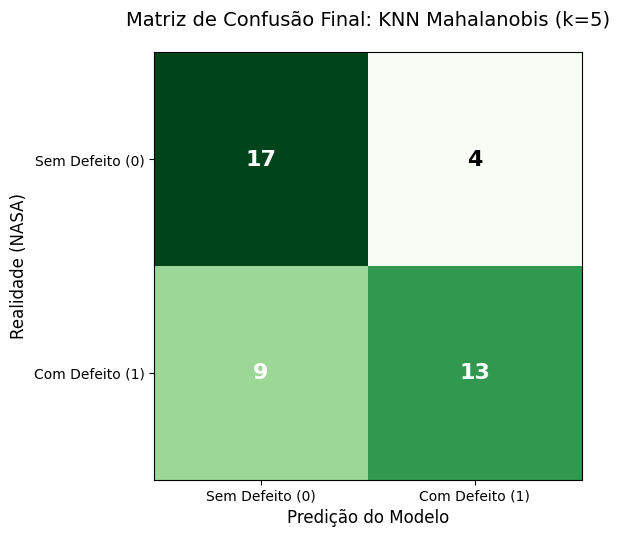

In [71]:
X_treino_norm = (X_treino - X_treino.mean(axis=0)) / X_treino.std(axis=0)
X_teste_norm = (X_teste - X_treino.mean(axis=0)) / X_treino.std(axis=0)

y_pred_final = []


S_final = np.cov(X_treino_norm.T) + np.eye(X_treino_norm.shape[1])
V_inv_final = np.linalg.inv(S_final)

for x in X_teste_norm:
    p = knn(X_treino_norm, y_treino, x, k=5, dist='mahalanobis', V_inv=V_inv_final)
    y_pred_final.append(p)

y_pred_final = np.array(y_pred_final)


vp = np.sum((y_teste == 1) & (y_pred_final == 1))
vn = np.sum((y_teste == 0) & (y_pred_final == 0))
fp = np.sum((y_teste == 0) & (y_pred_final == 1))
fn = np.sum((y_teste == 1) & (y_pred_final == 0))

conf_matrix = np.array([[vn, fp], 
                        [fn, vp]])


fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Greens)


classes = ['Sem Defeito (0)', 'Com Defeito (1)']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
plt.xlabel('Predição do Modelo', fontsize=12)
plt.ylabel('Realidade (NASA)', fontsize=12)
plt.title('Matriz de Confusão Final: KNN Mahalanobis (k=5)', fontsize=14, pad=20)


thresh = conf_matrix.max() / 2.
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(conf_matrix[i, j]),
                ha="center", va="center",
                color="white" if conf_matrix[i, j] > thresh else "black",
                fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()